In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import os

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse

In [29]:
by_day_data = '../data/schedule_data/processed_data/by_day_short_and_long/'
by_day_data_list = [x for x in os.listdir(by_day_data) if 'train.csv' in x]
dtypes = pd.read_csv(f'{os.path.join(by_day_data,by_day_data_list[0])}', nrows=1).iloc[0].to_dict()
print(dtypes)

def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path,
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])


{'date': 'datetime64[us]', 'EB/WB': 'str', 'stop': 'str', 'bunch': 'int64', 'gap': 'int64', 'delay time (5,19]': 'float64', 'delay time (19,120]': 'float64', 'No. of Veh': 'float64', 'Run time (min)': 'float64', 'Term time (min)': 'float64', 'Avg. spd (km/h)': 'float64', 'RT dist (km)': 'float64', 'Interruption': 'int64'}


In [30]:
daily_df = read_csv(by_day_data+by_day_data_list[0])
daily_df = daily_df[daily_df['date'].between(pd.Timestamp('2024-07-30'), pd.Timestamp('2025-09-01'), inclusive='left')]

daily_df = daily_df.rename(columns={'delay time (5,19]':'dt_short', 'delay time (19,120]':'dt_long', 'EB/WB':'dir'})

In [31]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),Avg. spd (km/h),RT dist (km),Interruption
0,2024-07-30,E,Indian Rd,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
1,2024-07-30,E,Coxwell Ave at Gerrard St East,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
2,2024-07-30,E,Grace St,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
3,2024-07-30,W,Woodbine Ave,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
4,2024-07-30,E,De Grassi St,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0


In [32]:
daily_df[daily_df.stop == 'Main St'].stop.unique()

array(['Main St'], dtype=object)

In [33]:
daily_df.date = daily_df.date.apply(pd.Timestamp)

In [34]:
# I want to add daily weather data. 
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [35]:
first_date = daily_df['date'].min()
last_date = daily_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]
weather.head()

,date,avg_temperature,avg_relative_humidity,avg_dew_point,avg_wind_speed,wind_gust_dir_10s,avg_pressure_station,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
197,2025-08-31,16.39,57.5,9.1,8.5,0.0,100.36,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:40:00,0 days 19:55:00,13.25,2.0
198,2025-08-30,15.00,58.5,7.5,13.0,31.0,99.96,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:39:00,0 days 19:57:00,13.30,3.5
199,2025-08-29,13.55,64.5,6.0,19.5,31.0,99.73,24100,1.7,0.0,0.0,0.0,0.0,0 days 06:38:00,0 days 19:59:00,13.35,4.0
200,2025-08-28,14.95,73.5,11.8,17.5,32.0,99.53,18500,2.2,5.4,5.4,0.0,0.0,0 days 06:36:00,0 days 20:00:00,13.40,4.0
201,2025-08-27,17.00,58.0,6.7,19.5,26.0,99.86,24100,2.1,0.0,0.0,0.0,0.0,0 days 06:35:00,0 days 20:02:00,13.45,3.0


In [36]:
daily_df = pd.merge(daily_df, weather, on='date')

In [37]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),...,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
0,2024-07-30,E,Indian Rd,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
1,2024-07-30,E,Coxwell Ave at Gerrard St East,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
2,2024-07-30,E,Grace St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
3,2024-07-30,W,Woodbine Ave,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
4,2024-07-30,E,De Grassi St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0


In [38]:
# Fill na values with 0
daily_df.fillna(0, inplace=True)

In [39]:
features = ['dir', 'bunch', 'gap', 'Interruption']+weather.columns.to_list()
targets = [x for x in daily_df.columns if 'dt_' in x]

In [40]:
corr_matrix = daily_df[features+targets].select_dtypes(np.number).corr()

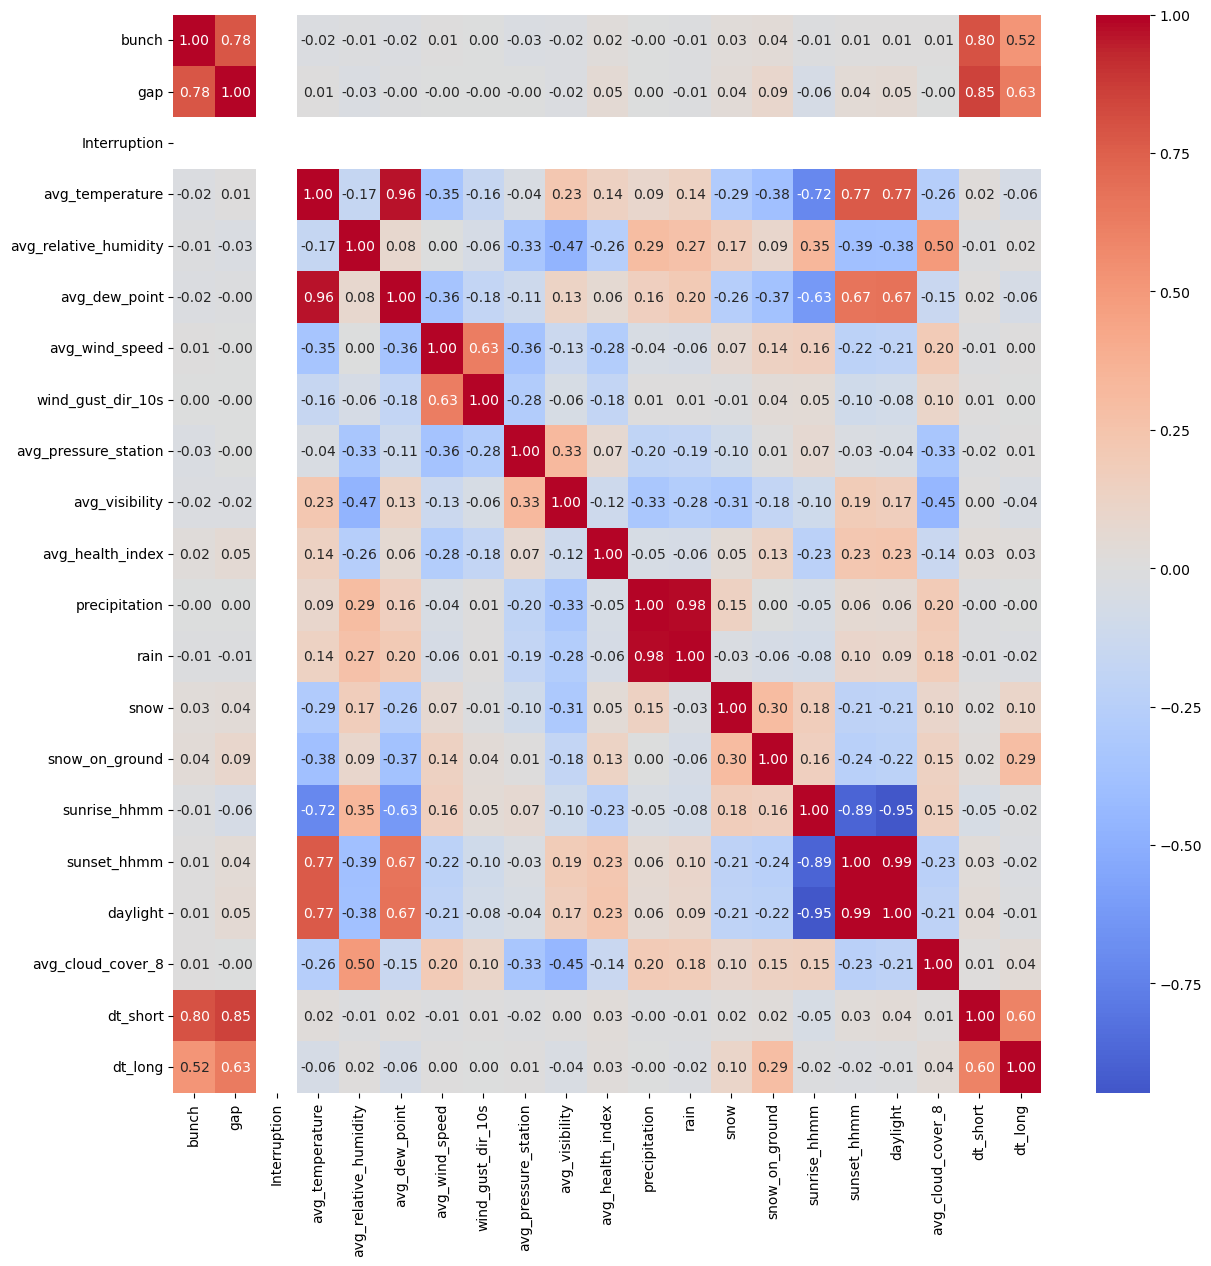

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,14))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f')
plt.show()

Most of these columns are either essentially repeats of other columns, or totally uncorrelated, except for the following features:
- Bunch, Gap, Interruption, avg_temperature, avg_wind_speed, avg_visibility, avg_health_index, rain, snow_on_ground, daylight

Interestingly, factors like windspeed seem to not play any role on the data.

Lets build a model around these features. First let's see a truncated version of the correlation matrix with only these features.

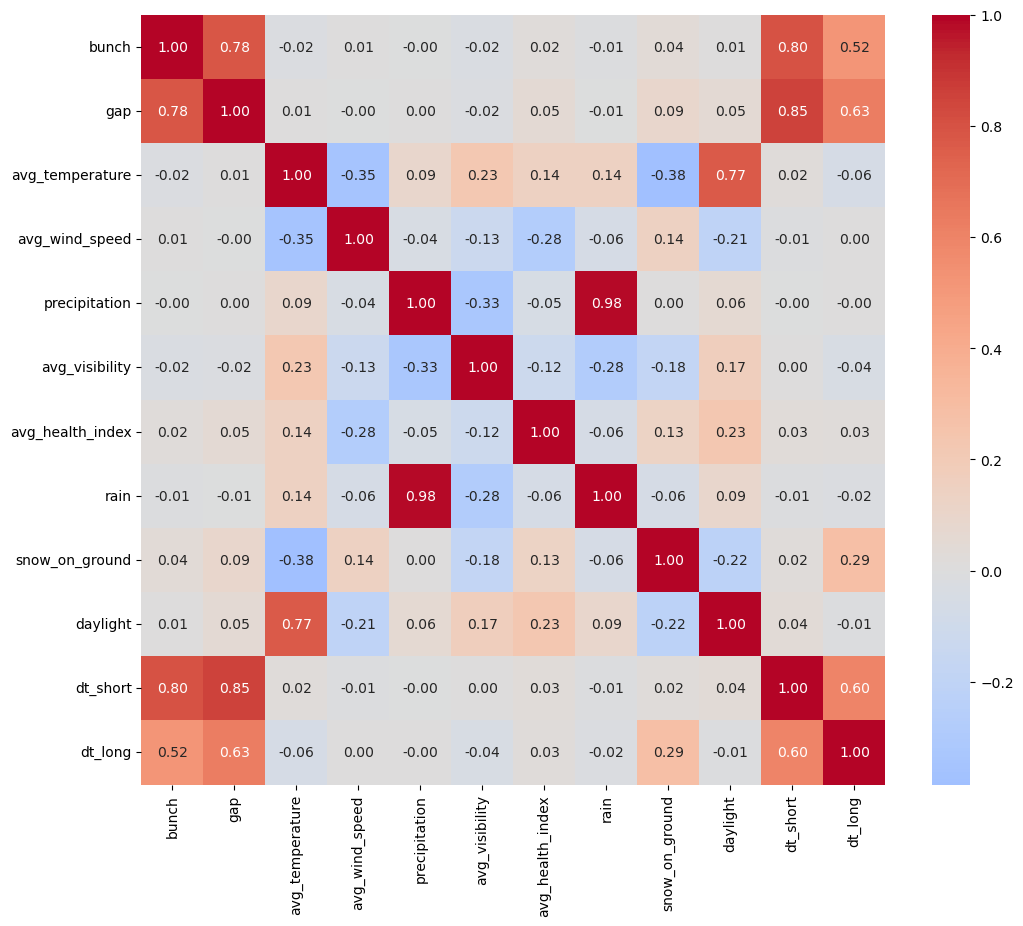

In [42]:
features = ['bunch', 'gap','avg_temperature', 'avg_wind_speed', 'precipitation', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight']
targets = [x for x in daily_df.columns if 'dt_' in x]

corr_matrix = daily_df[features+targets].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f');

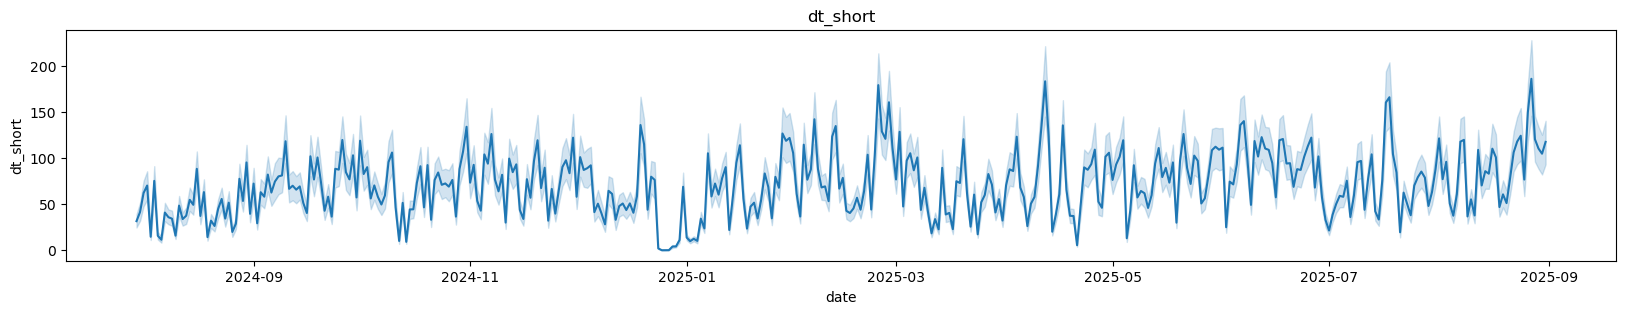

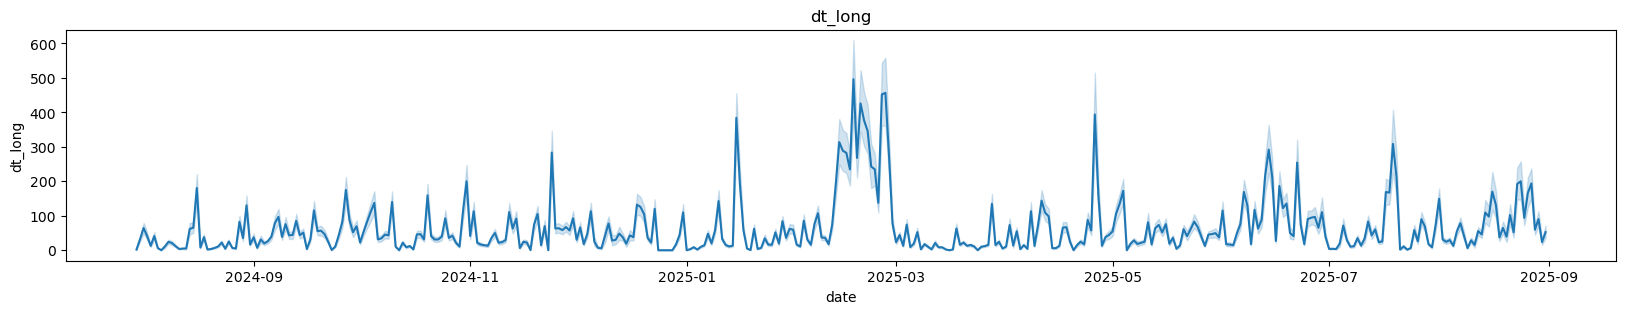

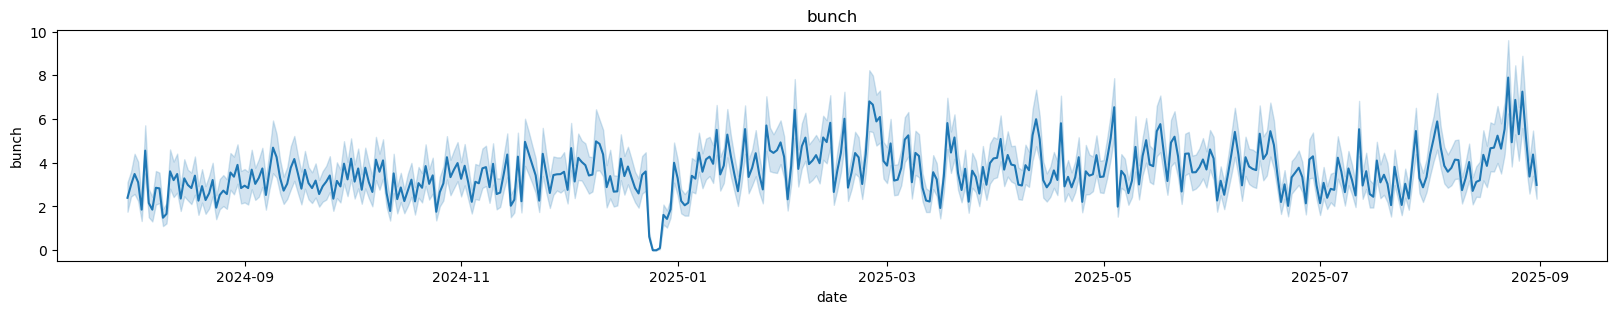

In [43]:
for dt in ['dt_short', 'dt_long']:
    plt.figure(figsize=(20,3))
    sns.lineplot(data=daily_df, x='date', y=dt)
    plt.title(dt)
    plt.show()

plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='bunch')
plt.title('bunch')
plt.show()

Some of the feature of the long term weight can be explained by snowfall.

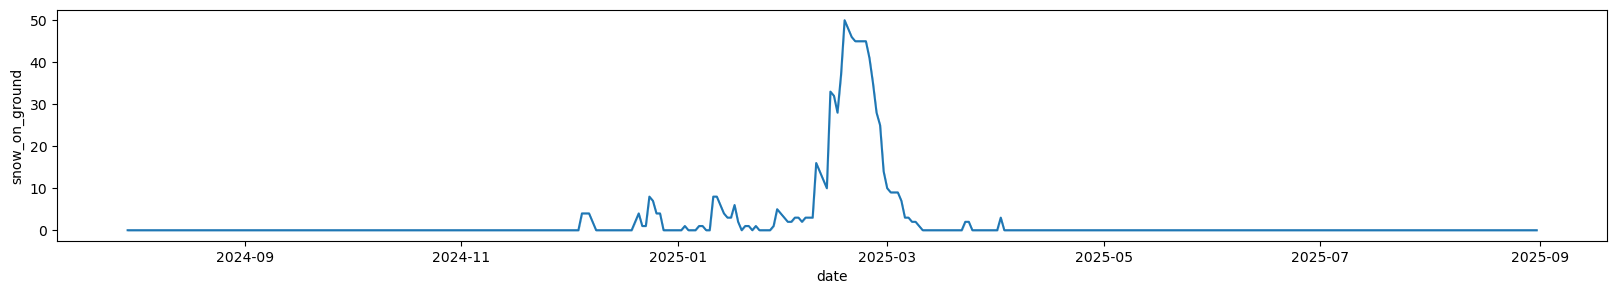

In [44]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='snow_on_ground')
plt.show()

Another region of 'spikes' corresponds to some of the hottest days of the year.

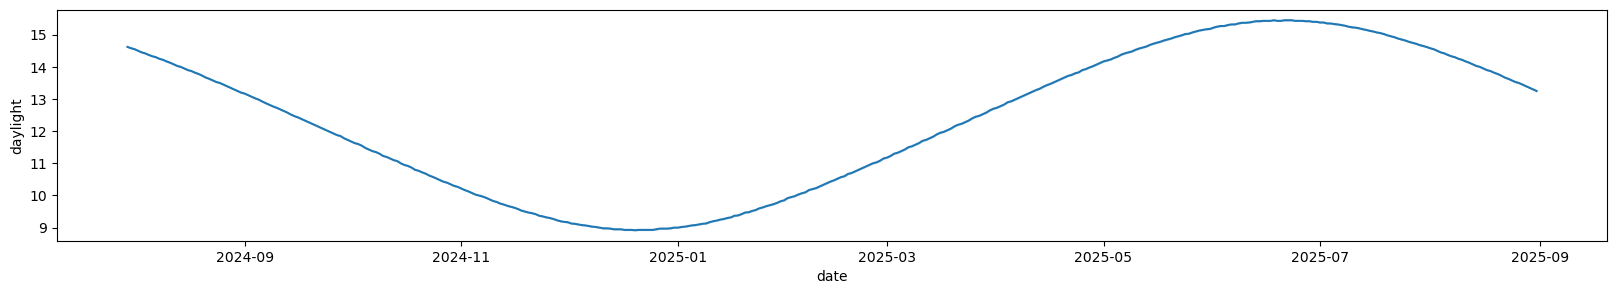

In [45]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='daylight')
plt.show()

The ACF and PACF plots show no strong correlation between bunch events per day.

In [46]:
def count_feature(date, feature, df):
    if len(df[df['date'] == date][feature].tolist())==0:
        return 0
    else:
        return sum(df[df['date'] == date][feature])

bunch_events = []
start_date = daily_df.date.min()
end_date = daily_df.date.max()
timedelta = (end_date - start_date).days
for delta in range(timedelta):
    bunch_events.append(count_feature(start_date+pd.Timedelta(days=delta), 'bunch', daily_df))

bunch_events = np.array(bunch_events)

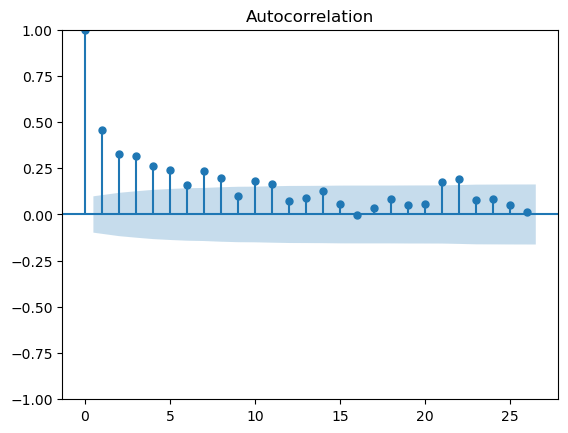

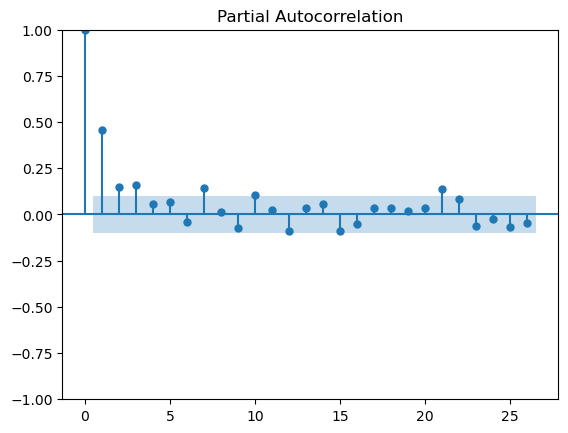

In [47]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
plot_acf(bunch_events)
plt.show()
plot_pacf(bunch_events)
plt.show()

We use xgboost since it's a very flexible model that generalizes well. According to (https://stats.stackexchange.com/questions/338904/measures-of-ordinal-classification-error-for-ordinal-regression)[this post on Cross Validated], RMSE is the best measure of performance for ordinal classification when the classes are reasonably balanced, and MAE should not be used. Note that 'dt_long' is *not* balanced, and so we will have to come to an analysis of this with a different metric.

In [48]:
# Let's try xgboost since it is a very flexible model
import xgboost as xgb
# First turn stop into a categorical feature.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

loss = dict()
R2_score = dict()
features = ['bunch', 'gap', 'avg_temperature', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain',
            'snow_on_ground',
            'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=100,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_alpha=4,
                                reg_lambda=0)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)

for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

print(R2_score)

dt_short rmse mean: 58.20608915172725
dt_short rmse std: 8.573875253059718
dt_short average R^2 score: 0.8468187591640042
dt_short R^2 score std: 0.04616006676254337

dt_long rmse mean: 63.19745899558137
dt_long rmse std: 33.86485003647519
dt_long average R^2 score: 0.475858986322896
dt_long R^2 score std: 0.18516914966726497

{('dt_short', 0): 0.7564056658847881, ('dt_short', 1): 0.8795142250865534, ('dt_short', 2): 0.8553045014969118, ('dt_short', 3): 0.8634867203294458, ('dt_short', 4): 0.879382683022322, ('dt_long', 0): 0.27558995783630225, ('dt_long', 1): 0.23083101188637722, ('dt_long', 2): 0.6571750781350403, ('dt_long', 3): 0.6501175862044803, ('dt_long', 4): 0.5655812975522799}


We're going to try to use Shapley values to do some analysis on the feature set, mimicking [Wendy's analysis on the effect of gender on pay](https://www.kaggle.com/code/manwaicheung/gender-pay-gap). One factor that we want to isolate is the direction of the streetcar.

In [49]:
import shap
shap.initjs()

In [63]:
df_filter = dict()
y_filter = dict()
X_filter= dict()
for target in ['dt_short', 'dt_long']:
    df_filter[target] = daily_df
    X_filter[target] = df_filter[target][[x for x in features]]
    y_filter[target] = df_filter[target][target]


In [64]:
model_filter = dict()
for key in df_filter.keys():
    model_filter[key] = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200,
    learning_rate=0.1,
    enable_categorical=True,
    max_depth=10,
    reg_alpha=2,
    reg_lambda=0,
    seed=37)
    model_filter[key].fit(X_filter[key], y_filter[key])

In [65]:
explainer_filter = dict()
shap_filter = dict()
for key in df_filter.keys():
    explainer_filter[key] = shap.Explainer(model_filter[key])
    shap_filter[key] = explainer_filter[key](X_filter[key])

Lets first see a waterfall plot to see how our function compares to the baseline

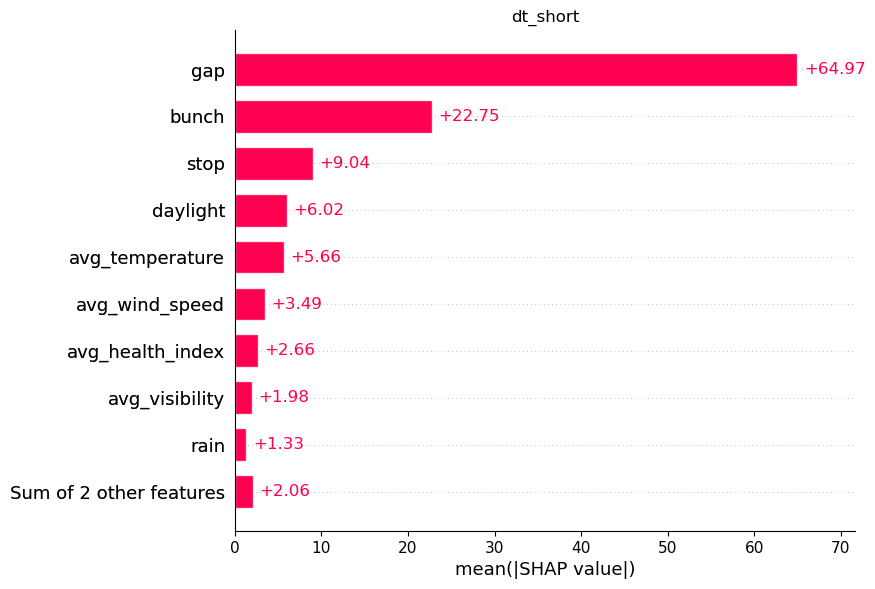

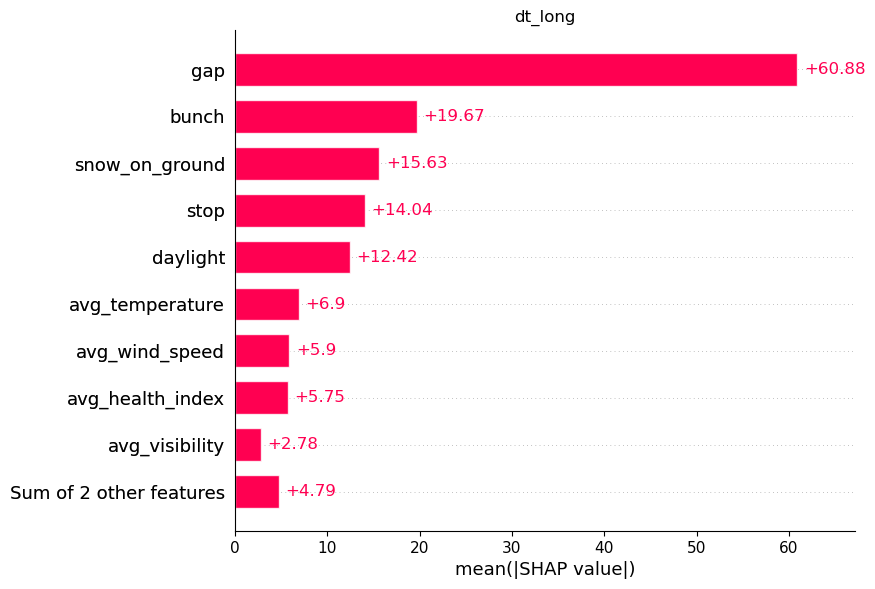

In [66]:
for key in df_filter.keys():
    shap.plots.bar(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

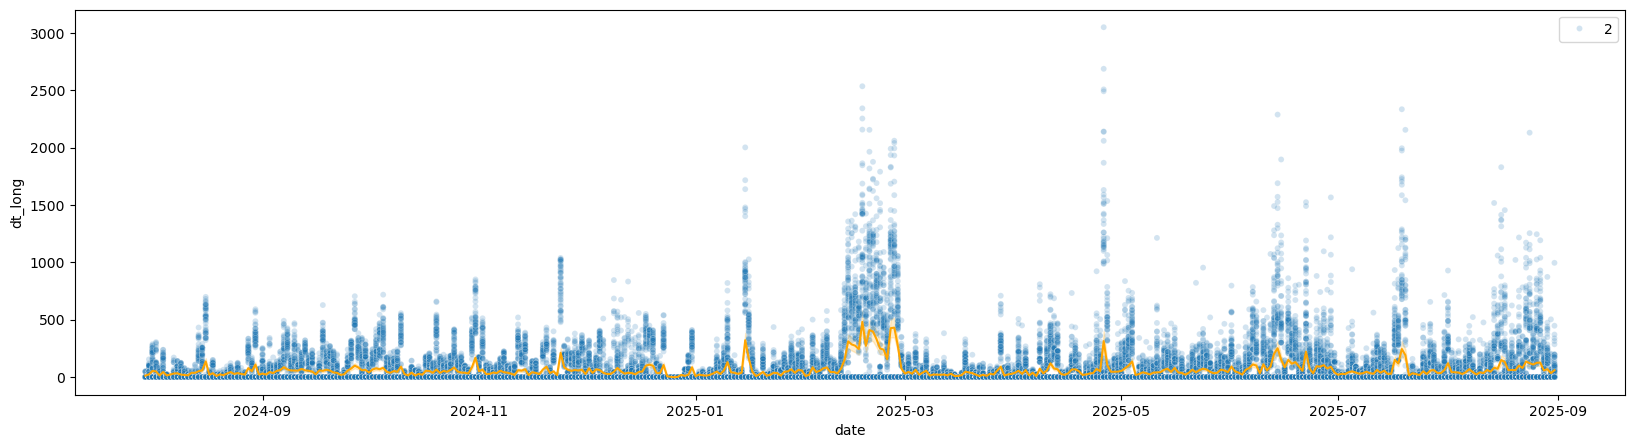

In [107]:
model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=100,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=5,
                                reg_alpha=0,
                                reg_lambda=0)

X = daily_df[features]
y = daily_df['dt_long']

model.fit(X,y)

y_pred = model.predict(X)

plt.figure(figsize= (20,5))
sns.lineplot(x=daily_df['date'], y= y_pred, c='orange')
sns.scatterplot(x=daily_df['date'], y= y, size=2, alpha=0.2)
plt.show()

In [99]:
stops = daily_df['stop'].unique()
baseline = dict()
for stop in stops:
    for dir in ['E', 'W']:
        baseline[dir, stop] = daily_df[(daily_df['stop'] == stop) & (daily_df['dir'] == dir)].dt_short.mean()

In [100]:
test_df = daily_df.copy()
test_df.drop('dt_short', axis=1, inplace=True)
dt_short = []
for row in range(test_df.shape[0]):
    curr_stop = test_df['stop'].iloc[row]
    curr_dir = test_df['dir'].iloc[row]
    dt_short.append(baseline[curr_dir, curr_stop])

test_df['dt_short'] = dt_short

83.54297736287096
-0.346602501986667


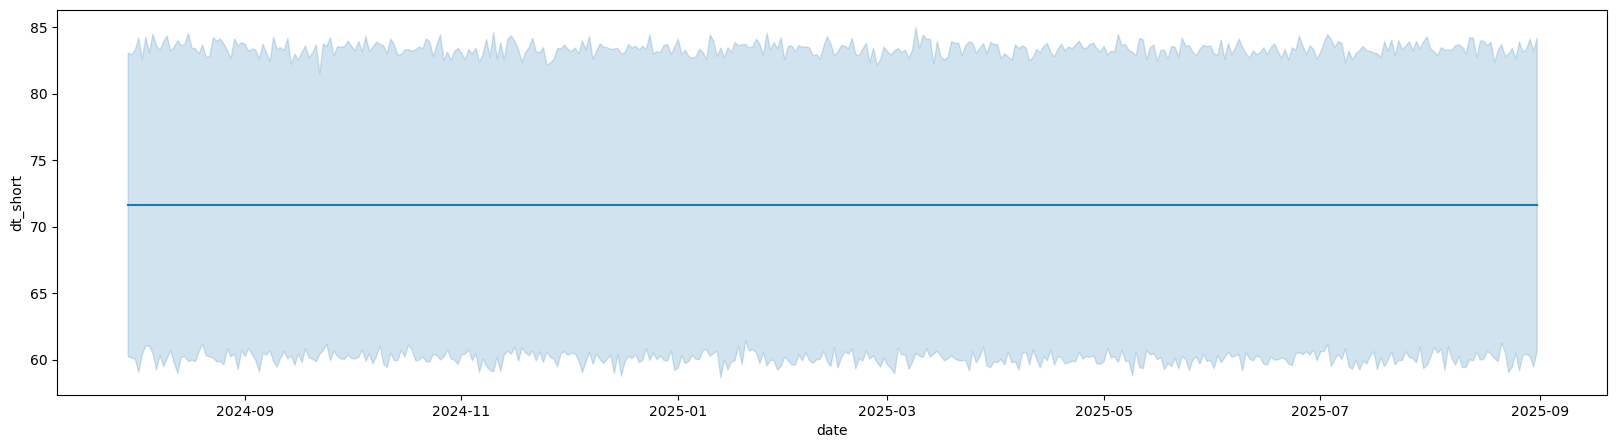

In [106]:
plt.figure(figsize= (20,5))
sns.lineplot(data=test_df, x='date', y='dt_short')
print(rmse(test_df['dt_short'], y))
print(r2_score(test_df['dt_short'], y))

That gap seems to be so dominant is very suspicious, especially since gapping events are defined as gaps between streetcars that are at least 19 minutes long. Therefore, we rerun the model without it.

In [58]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=200,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_lambda=2,
                                reg_alpha=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)
for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

print(R2_score)

dt_short rmse mean: 51.272356595247665
dt_short rmse std: 17.87787731141973
dt_short average R^2 score: 0.8751242043260274
dt_short R^2 score std: 0.07314735615042228

dt_long rmse mean: 54.3889508336134
dt_long rmse std: 21.881321711317163
dt_long average R^2 score: 0.5501774756603919
dt_long R^2 score std: 0.21876689643345545

{('dt_short', 0): 0.7631476199580652, ('dt_short', 1): 0.8136851646097882, ('dt_short', 2): 0.91937149626034, ('dt_short', 3): 0.9313682369397411, ('dt_short', 4): 0.9480485038622031, ('dt_long', 0): 0.7222781010559746, ('dt_long', 1): 0.36817020447209037, ('dt_long', 2): 0.21314325782314858, ('dt_long', 3): 0.7608867140308609, ('dt_long', 4): 0.686409100919885}


Let us do some hyperparameter tuning on this model.

In [59]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
target = 'dt_short'
lambda_vals = [0,1,3,5,10,20]
alpha_vals = [0,1,3,5,10,20]
depth_vals = [5,10,15,20]
est_vals = [100,200]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [60]:
for param in params.keys():
    print(f'param: {param}')
    print(f'{target} rmse mean: {np.array([val for key,val in loss.items() if key[0] == param]).mean()}')
    print(f'{target} rmse std: {np.array([val for key,val in loss.items() if key[0] == param]).std()}')

param: (0, 0, 5, 100)
dt_short rmse mean: 74.10218065972998
dt_short rmse std: 14.20222879240852
param: (0, 0, 5, 200)
dt_short rmse mean: 61.994710238769336
dt_short rmse std: 16.21622234621339
param: (0, 0, 10, 100)
dt_short rmse mean: 55.77340438658236
dt_short rmse std: 15.807411804180527
param: (0, 0, 10, 200)
dt_short rmse mean: 53.09270626039499
dt_short rmse std: 14.512087694309889
param: (0, 0, 15, 100)
dt_short rmse mean: 56.45674172376778
dt_short rmse std: 13.74114352004543
param: (0, 0, 15, 200)
dt_short rmse mean: 56.403104941308676
dt_short rmse std: 13.858473472704707
param: (0, 0, 20, 100)
dt_short rmse mean: 64.83053360182905
dt_short rmse std: 13.534403208213416
param: (0, 0, 20, 200)
dt_short rmse mean: 64.82759065637474
dt_short rmse std: 13.541892665536583
param: (0, 1, 5, 100)
dt_short rmse mean: 74.60036583246823
dt_short rmse std: 15.117144073541896
param: (0, 1, 5, 200)
dt_short rmse mean: 62.114816817513464
dt_short rmse std: 17.133737650289067
param: (0, 1, 

In [61]:
best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

37.93766490858006 (0, 0, 10, 200) 0.890579286367054 (20, 3, 15, 200)
[72.23157590046621, 66.99218821893868, 36.942381171102895, 51.359721102887065, 37.93766490858006]
[0.7921545244632414, 0.8210879669435333, 0.9224783228481918, 0.8870604885603681, 0.9320731645390873]
[68.9094449940967, 64.2794522299628, 29.21456933196224, 44.55667616598477, 35.577721207305366]
[0.8108336435449677, 0.8352840870457361, 0.9515189109620037, 0.9149985834909281, 0.9402612067916339]


In [62]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
target = 'dt_long'
lambda_vals = [0,1,3,5,10,20]
alpha_vals = [0,1,3,5,10,20]
depth_vals = [5,10,15,20]
est_vals = [100,200]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

KeyboardInterrupt: 

In [ ]:
for param in params.keys():
    print(f'param: {param}')
    print(f'{target} rmse mean: {np.array([val for key,val in loss.items() if key[0] == param]).mean()}')
    print(f'{target} rmse std: {np.array([val for key,val in loss.items() if key[0] == param]).std()}')
    print(f'{target} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == param]).mean()}')
    print(f'{target} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == param]).std()}\n')

In [ ]:
best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

Actually, the second model does pretty well in general, so I think I will use these parameters for my final analysis.

In [ ]:
df_filter = dict()
y_filter = dict()
X_filter= dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']
for target in ['dt_short', 'dt_long']:
    df_filter[target] = daily_df
    X_filter[target] = df_filter[target][[x for x in features]]
    y_filter[target] = df_filter[target][target]

model_filter = dict()
for key in df_filter.keys():
    model_filter[key] = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100,
    learning_rate=0.1,
    enable_categorical=True,
    max_depth=5,
    reg_lambda=4,
    reg_alpha=0,
    seed=37)
    model_filter[key].fit(X_filter[key], y_filter[key])

explainer_filter = dict()
shap_filter = dict()
for key in df_filter.keys():
    explainer_filter[key] = shap.Explainer(model_filter[key])
    shap_filter[key] = explainer_filter[key](X_filter[key])

for key in df_filter.keys():
    shap.plots.bar(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

Finally, we can look at the distribution of the features.

In [ ]:
for key in df_filter.keys():
    shap.plots.beeswarm(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

In fact, the short term delay time is also a strong predictor for the amount of gap events, suggesting that gap does not make a good feature for prediction.

In [ ]:
loss = dict()
R2_score = dict()
features = ['dt_short', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['bunch','gap']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=100,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_lambda=5,
                                reg_alpha=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)

for dt in ['bunch','gap']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')


Some hyperparameter tuning to try to see if 'bunch' can be predicted from the above information.

In [ ]:
loss = dict()
R2_score = dict()
features = ['dt_short', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
target = 'bunch'
lambda_vals = [0,1,3,5,10,20]
alpha_vals = [0,1,3,5,10,20]
depth_vals = [5,10,15,20]
est_vals = [100,200]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [ ]:
for param in params.keys():
    print(f'param: {param}')
    print(f'{target} rmse mean: {np.array([val for key,val in loss.items() if key[0] == param]).mean()}')
    print(f'{target} rmse std: {np.array([val for key,val in loss.items() if key[0] == param]).std()}')
    print(f'{target} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == param]).mean()}')
    print(f'{target} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == param]).std()}\n')

best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

In [ ]:
print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

This is pretty bad, which adds to evidence that bunch events alone cannot predict delays. Finally, we try the other way around.

In [ ]:
loss = dict()
R2_score = dict()
features = ['bunch', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
target = 'dt_short'
lambda_vals = [0,1,3,5,10,20]
alpha_vals = [0,1,3,5,10,20]
depth_vals = [5,10,15,20]
est_vals = [100,200]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [ ]:
for param in params.keys():
    print(f'param: {param}')
    print(f'{target} rmse mean: {np.array([val for key,val in loss.items() if key[0] == param]).mean()}')
    print(f'{target} rmse std: {np.array([val for key,val in loss.items() if key[0] == param]).std()}')
    print(f'{target} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == param]).mean()}')
    print(f'{target} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == param]).std()}\n')

best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

In [ ]:
print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

A much better predictor, which is a good sign.

In [ ]:
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']
tss = TimeSeriesSplit(n_splits=2, test_size=120)
tss_split = tss.split(daily_df, daily_df.date)
next(tss_split)
tss_train, tss_test = next(tss_split)

df_train = daily_df.iloc[tss_train]
df_test = daily_df.iloc[tss_test]

dt = 'dt_long'

model = xgb.XGBRegressor(objective='reg:squarederror',
                        n_estimators=200,
                        enable_categorical=True,
                        learning_rate=0.1,
                        max_depth=10,
                        reg_alpha=2,
                        reg_lambda=0,
                        seed=37)

X_train = df_train[features]
y_train = df_train[dt]


X_test = df_test[features]
y_test = df_test[dt]


model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

df_pred = df_test.copy()
df_pred[dt] = y_pred


df_pred_train = df_train.copy()
df_pred_train[dt] = y_pred_train

In [ ]:
plt.figure(figsize=(20,5))
sns.lineplot(x=range(120), y=y_test)
sns.lineplot(x=range(120), y=y_pred)